In [1]:
import warnings, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from itertools import product
from sklearn.base import clone
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay, precision_recall_curve
)

In [2]:
from google.colab import drive
drive.mount('/content/drive/')

file_path = '/content/drive/MyDrive/Group Work_Pipeline_Last.csv'
df = pd.read_csv(file_path, on_bad_lines="skip")

Mounted at /content/drive/


In [3]:
target_col = 'is_fit'
assert target_col in df.columns, f"{target_col} not found in columns: {df.columns.tolist()}"
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [4]:
# Define SVC pipeline + conditional grid (variety)
# -----------------------------
svc_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC())
])

In [5]:
# Conditional grid to avoid irrelevant gamma for linear
svc_param_grid = [
    {
        'svc__kernel': ['linear'],
        'svc__C': [0.1, 1, 10, 100],
        'svc__class_weight': [None, 'balanced']
    },
    {
        'svc__kernel': ['rbf'],
        'svc__C': [0.1, 1, 10, 100],
        'svc__gamma': ['scale', 'auto', 0.01, 0.1, 1.0],
        'svc__class_weight': [None, 'balanced']
    }
]

In [6]:
# Count candidate parameter combinations programmatically
def count_candidates(param_grid_list):
    total = 0
    for g in param_grid_list:
        sizes = [len(v) for v in g.values()]
        c = 1
        for s in sizes:
            c *= s
        total += c
    return total

n_candidates = count_candidates(svc_param_grid)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
try:
    n_splits = cv.get_n_splits()
except Exception:
    n_splits = 5

print(f"SVC candidate combinations: {n_candidates}")
print(f"Total CV fits: {n_candidates * n_splits} (with {n_splits}-fold Stratified CV)")
print("Grid (variety): kernels={linear, rbf}, C={0.1,1,10,100}, "
      "gamma={scale,auto,0.01,0.1,1} for RBF only, class_weight={None,balanced}")

SVC candidate combinations: 48
Total CV fits: 240 (with 5-fold Stratified CV)
Grid (variety): kernels={linear, rbf}, C={0.1,1,10,100}, gamma={scale,auto,0.01,0.1,1} for RBF only, class_weight={None,balanced}


In [7]:
# Grid search (optimize F1)
SCORING = 'f1'  # change to 'balanced_accuracy' or 'roc_auc' if preferred
t0 = time.perf_counter()
grid = GridSearchCV(
    svc_pipe, svc_param_grid, scoring=SCORING, cv=cv, n_jobs=-1, refit=True, verbose=1
)
grid.fit(X_train, y_train)
print("Best params (overall):", grid.best_params_)
print(f"GridSearch time: {time.perf_counter() - t0:.1f}s")

# CV leaderboard (top 10 by mean_test_score)
cvres = pd.DataFrame(grid.cv_results_)
leaderboard_cols = ['param_svc__kernel','param_svc__C','param_svc__gamma','param_svc__class_weight',
                    'mean_test_score','std_test_score','mean_fit_time']
# Some rows (linear kernel) have NaN gamma; that's fine to display
print("\n=== CV Top 10 (by mean_test_score) ===")
print(cvres.sort_values('mean_test_score', ascending=False)[leaderboard_cols].head(10).to_string(index=False))

# Best-per-kernel params from CV (variety comparison without re-search)
def best_params_for_kernel(cvres_df, kernel_name):
    dfk = cvres_df[cvres_df['param_svc__kernel'] == kernel_name]
    if len(dfk) == 0:
        return None
    row = dfk.sort_values('mean_test_score', ascending=False).iloc[0]
    return row['params']

best_params_linear = best_params_for_kernel(cvres, 'linear')
best_params_rbf = best_params_for_kernel(cvres, 'rbf')
print("\nBest params (linear):", best_params_linear)
print("Best params (rbf):", best_params_rbf)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best params (overall): {'svc__C': 1, 'svc__class_weight': 'balanced', 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}
GridSearch time: 44.3s

=== CV Top 10 (by mean_test_score) ===
param_svc__kernel  param_svc__C param_svc__gamma param_svc__class_weight  mean_test_score  std_test_score  mean_fit_time
              rbf           1.0             0.01                balanced         0.755929        0.026209       0.138671
              rbf          10.0             0.01                balanced         0.753717        0.019233       0.084223
           linear         100.0              NaN                balanced         0.751975        0.018554       3.024099
           linear          10.0              NaN                balanced         0.751975        0.018554       0.307432
           linear           1.0              NaN                balanced         0.751556        0.019619       0.099801
           linear           0.1      

In [8]:
# Evaluation helpers
# -----------------------------
def evaluate_model(model, name):
    y_pred = model.predict(X_test)
    # Scores for ROC/PR
    if hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    elif hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = y_pred  # fallback (not ideal for AUC)
    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "precision_1": precision_score(y_test, y_pred, zero_division=0),
        "recall_1": recall_score(y_test, y_pred, zero_division=0),
        "f1_1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score),
        "pr_auc": average_precision_score(y_test, y_score),
        "confusion_matrix": confusion_matrix(y_test, y_pred),
        "report": classification_report(y_test, y_pred, digits=3),
        "scores": y_score
    }
    return metrics

In [9]:
# Fit best-overall (already fitted by grid), plus best-per-kernel clones
best_overall = grid.best_estimator_
metrics_overall = evaluate_model(best_overall, "SVC (best overall)")

models = [metrics_overall]
roc_curves = [("SVC (best overall)", metrics_overall["scores"])]

# Best linear
if best_params_linear is not None:
    best_linear = clone(svc_pipe).set_params(**best_params_linear).fit(X_train, y_train)
    metrics_linear = evaluate_model(best_linear, "SVC (best linear)")
    models.append(metrics_linear)
    roc_curves.append(("SVC (best linear)", metrics_linear["scores"]))

# Best RBF
if best_params_rbf is not None:
    best_rbf = clone(svc_pipe).set_params(**best_params_rbf).fit(X_train, y_train)
    metrics_rbf = evaluate_model(best_rbf, "SVC (best rbf)")
    models.append(metrics_rbf)
    roc_curves.append(("SVC (best rbf)", metrics_rbf["scores"]))


In [10]:
# Threshold tuning for best-overall (optional variety)
# -----------------------------
# Choose threshold that maximizes F1 for class 1
scores = metrics_overall["scores"]
prec, rec, thr = precision_recall_curve(y_test, scores)
f1s = 2 * (prec * rec) / (prec + rec + 1e-12)
best_idx = np.nanargmax(f1s)
best_thr = thr[max(best_idx-1, 0)] if best_idx < len(thr) else 0.0
y_pred_thr = (scores >= best_thr).astype(int)

metrics_thr = {
    "model": f"SVC (best overall) @thr={best_thr:.3f}",
    "accuracy": accuracy_score(y_test, y_pred_thr),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_thr),
    "precision_1": precision_score(y_test, y_pred_thr, zero_division=0),
    "recall_1": recall_score(y_test, y_pred_thr, zero_division=0),
    "f1_1": f1_score(y_test, y_pred_thr, zero_division=0),
    "roc_auc": roc_auc_score(y_test, scores),  # AUC doesn't depend on threshold
    "pr_auc": average_precision_score(y_test, scores),
    "confusion_matrix": confusion_matrix(y_test, y_pred_thr),
    "report": classification_report(y_test, y_pred_thr, digits=3)
}
models.append(metrics_thr)

In [11]:
# Results summary and prints
# -----------------------------
summary = pd.DataFrame([
    {k: v for k, v in m.items() if k not in ("confusion_matrix","report","scores")}
    for m in models
])
print("\n=== Test Set Comparison (SVC varieties) ===")
print(summary.sort_values('f1_1', ascending=False).to_string(index=False))

for m in models:
    print(f"\n--- {m['model']} ---")
    print("Confusion Matrix:\n", m["confusion_matrix"])
    print(m["report"])


=== Test Set Comparison (SVC varieties) ===
                         model  accuracy  balanced_accuracy  precision_1  recall_1     f1_1  roc_auc   pr_auc
SVC (best overall) @thr=-0.242  0.785166           0.795417     0.687500  0.846154 0.758621 0.848691 0.776928
             SVC (best linear)  0.767263           0.768672     0.683616  0.775641 0.726727 0.848827 0.773136
            SVC (best overall)  0.767263           0.764362     0.692308  0.750000 0.720000 0.848691 0.776928
                SVC (best rbf)  0.767263           0.764362     0.692308  0.750000 0.720000 0.848691 0.776928

--- SVC (best overall) ---
Confusion Matrix:
 [[183  52]
 [ 39 117]]
              precision    recall  f1-score   support

           0      0.824     0.779     0.801       235
           1      0.692     0.750     0.720       156

    accuracy                          0.767       391
   macro avg      0.758     0.764     0.760       391
weighted avg      0.772     0.767     0.769       391


--- SVC

<Figure size 600x500 with 0 Axes>

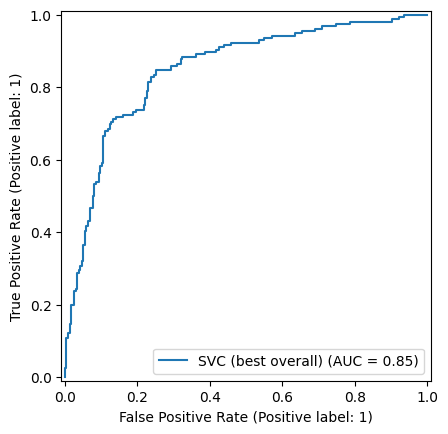

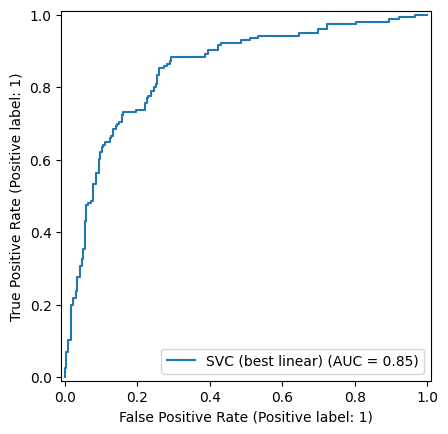

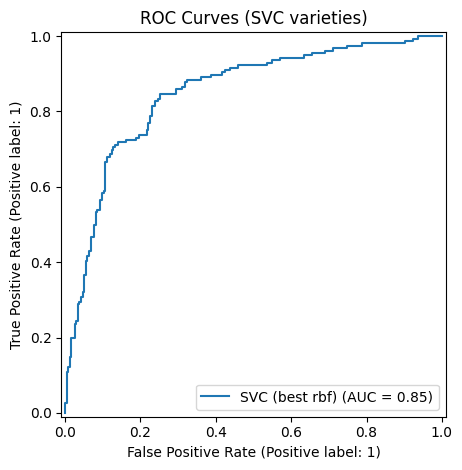

In [13]:
# Plots
# ROC curves
plt.figure(figsize=(6,5))
for name, s in roc_curves:
    RocCurveDisplay.from_predictions(y_test, s, name=name)
plt.title("ROC Curves (SVC varieties)")
plt.tight_layout()
plt.show()


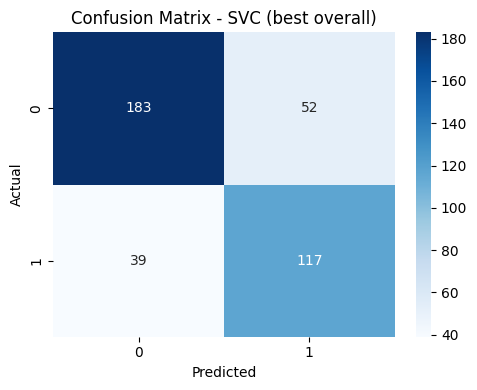

In [14]:
# Confusion matrix heatmap for best-overall
cm = models[0]["confusion_matrix"]
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.title("Confusion Matrix - SVC (best overall)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout()
plt.show()

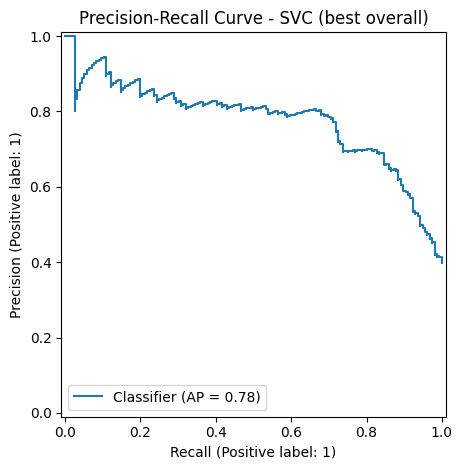

In [15]:
# PR curve (best-overall)
PrecisionRecallDisplay.from_predictions(y_test, models[0]["scores"])
plt.title("Precision-Recall Curve - SVC (best overall)")
plt.tight_layout()
plt.show()